# 🎬 Item-Based Collaborative Filtering Lab
**Dataset:** MovieLens 100K (`u.data`)  |  **Goal:** Recommend items similar to a given item

---
### In-Lab Tasks
1. Load real dataset (`u.data`)
2. Create Item-User matrix
3. Compute item similarity (Cosine)
4. Identify top similar items
5. Recommend items based on user history
6. Compare item-based vs user-based recommendations
7. Evaluate model — RMSE & Precision@K

### Visualizations
- V1: Item similarity heatmap
- V2: Top similar items graph
- V3: Item-based recommendation chart
- V4: User-based recommendation chart
- V5: Recommendation comparison chart
- V6: Popular vs niche items
- V7: Evaluation metrics bar chart

## 0. Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = "#4361EE"
ACCENT  = "#F72585"
K       = 10          # top-K used throughout

print("Libraries loaded ✓")

Libraries loaded ✓


## Step 1: Load Dataset
Loading the real **MovieLens 100K** dataset from `u.data`.
The file is tab-separated with columns: `user_id`, `item_id`, `rating`, `timestamp`.

In [20]:
df = pd.read_csv(
    r'../data/u.data',
    sep='\t',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)
print(f'Dataset loaded  →  shape: {df.shape}')
df.head()

Dataset loaded  →  shape: (100000, 4)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [21]:
print("── Dataset Info ──────────────────────────────")
print(df.info())
print()
print("── Describe ──────────────────────────────────")
display(df.describe())
print()
print("── Missing Values ────────────────────────────")
print(df.isnull().sum())
print()
print("── Unique Counts ─────────────────────────────")
print(f"Users        : {df.user_id.nunique()}")
print(f"Items        : {df.item_id.nunique()}")
print(f"Rating range : {df.rating.min()} – {df.rating.max()}")

── Dataset Info ──────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

── Describe ──────────────────────────────────


,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08



── Missing Values ────────────────────────────
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

── Unique Counts ─────────────────────────────
Users        : 943
Items        : 1682
Rating range : 1 – 5


## Step 2: Create Item-User Matrix
Pivot so rows = items, columns = users, values = ratings. Missing entries filled with 0.

In [22]:
item_user = df.pivot_table(
    index      = 'item_id',
    columns    = 'user_id',
    values     = 'rating',
    fill_value = 0
)

print(f"Item-User matrix shape : {item_user.shape}  (items × users)")
print(f"Sparsity               : {100*(item_user==0).values.mean():.1f}%")
item_user.iloc[:5, :8]

Item-User matrix shape : (1682, 943)  (items × users)
Sparsity               : 93.7%


user_id,1,2,3,4,5,6,7,8
item_id,,,,,,,,
1,5.0,4.0,0.0,0.0,4.0,4.0,0.0,0.0
2,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 3: Compute Item Similarity (Cosine)
We use the **top-200 most-rated items** to keep computation fast. Cosine similarity = 1.0 means identical rating patterns, 0.0 means no overlap.

In [23]:
SAMPLE     = 200
top_items  = df.item_id.value_counts().head(SAMPLE).index.tolist()
sub_matrix = item_user.loc[item_user.index.isin(top_items)]

cos_sim = cosine_similarity(sub_matrix)
cos_df  = pd.DataFrame(cos_sim,
                        index   = sub_matrix.index,
                        columns = sub_matrix.index)

print(f"Similarity matrix shape  : {cos_df.shape}")
print(f"Diagonal mean (self-sim) : {np.diag(cos_sim).mean():.4f}  ← must be 1.0")
print(f"Off-diagonal mean        : {cos_sim[np.triu_indices_from(cos_sim,1)].mean():.4f}")
cos_df.iloc[:5, :5]

Similarity matrix shape  : (200, 200)
Diagonal mean (self-sim) : 1.0000  ← must be 1.0
Off-diagonal mean        : 0.3695


item_id,1,4,7,8,9
item_id,,,,,
1,1.000000,0.454938,0.620979,0.481114,0.496288
4,0.454938,1.000000,0.489283,0.490236,0.419044
7,0.620979,0.489283,1.000000,0.423515,0.527462
8,0.481114,0.490236,0.423515,1.000000,0.424429
9,0.496288,0.419044,0.527462,0.424429,1.000000


## Step 4: Identify Top Similar Items

In [24]:
def top_similar(item_id, sim_df, k=10):
    """Return top-k items most similar to item_id (excluding itself)."""
    row = sim_df.loc[item_id].drop(item_id)
    return row.nlargest(k)

SEED_ITEM = sub_matrix.index[0]      # most-rated item
top_k     = top_similar(SEED_ITEM, cos_df, K)

print(f"Seed item : {SEED_ITEM}")
print(f"\nTop-{K} similar items:")
print(top_k.to_string())

Seed item : 1

Top-10 similar items:
item_id
50     0.734572
181    0.699925
121    0.689786
117    0.664555
405    0.641322
151    0.638158
222    0.636727
100    0.630601
237    0.624075
174    0.622382


## Step 5: Recommend Items Based on User History (Item-Based CF)
For each item the user has rated, we find similar items and accumulate a weighted score (similarity × rating). Highest-scoring unrated items are recommended.

In [25]:
def item_based_recommend(user_id, df, sim_df, k=10):
    """Item-based CF: recommend top-k items for a given user."""
    rated = df[df.user_id == user_id].set_index('item_id')['rating']
    scores = {}
    for iid, r in rated.items():
        if iid not in sim_df.index:
            continue
        sims = sim_df.loc[iid].drop(rated.index, errors='ignore')
        for jid, s in sims.items():
            scores[jid] = scores.get(jid, 0) + s * r
    return pd.Series(scores).nlargest(k)

SAMPLE_USER = 1
item_recs   = item_based_recommend(SAMPLE_USER, df, cos_df, K)

print(f"Item-Based Top-{K} Recommendations for User {SAMPLE_USER}:")
print(item_recs.to_string())

Item-Based Top-10 Recommendations for User 1:
423    236.535654
568    218.928737
655    216.677811
385    214.483292
318    214.251259
357    211.483936
403    209.884661
496    205.734258
405    204.447811
483    203.067327


## Step 6: Compare Item-Based vs User-Based Recommendations
User-based CF finds similar users and recommends what they liked.

> ⚠️ **Important:** We include **all active users** (≥5 ratings) — NOT just a subsample — so that the target user is always present in the similarity matrix.

In [26]:
# Build user-user similarity — ALL active users included
user_item    = df.pivot_table(index='user_id', columns='item_id',
                               values='rating', fill_value=0)
active_users = df.user_id.value_counts()[df.user_id.value_counts() >= 5].index
sub_user     = user_item.loc[user_item.index.isin(active_users)]

print(f"Users in similarity matrix  : {len(sub_user)}")
print(f"User {SAMPLE_USER} in matrix        : {SAMPLE_USER in sub_user.index}  ← must be True")

u_cos    = cosine_similarity(sub_user)
u_cos_df = pd.DataFrame(u_cos, index=sub_user.index, columns=sub_user.index)

def user_based_recommend(user_id, df, u_sim_df, k=10):
    """User-based CF: recommend top-k items for a given user."""
    if user_id not in u_sim_df.index:
        print(f"  ⚠ User {user_id} not in matrix!")
        return pd.Series(dtype=float)
    rated         = set(df[df.user_id == user_id]['item_id'])
    similar_users = u_sim_df.loc[user_id].drop(user_id).nlargest(20).index
    scores = {}
    for su in similar_users:
        for _, row in df[df.user_id == su].iterrows():
            if row.item_id not in rated:
                s = u_sim_df.loc[user_id, su]
                scores[row.item_id] = scores.get(row.item_id, 0) + s * row.rating
    return pd.Series(scores).nlargest(k)

user_recs = user_based_recommend(SAMPLE_USER, df, u_cos_df, K)

print(f"\nUser-Based Top-{K} Recommendations for User {SAMPLE_USER}:")
print(user_recs.to_string())

Users in similarity matrix  : 943
User 1 in matrix        : True  ← must be True

User-Based Top-10 Recommendations for User 1:
474    41.009939
423    38.334786
318    37.412945
357    37.131466
655    36.831150
403    35.621204
433    34.771189
651    34.406157
568    34.181974
732    32.603549


In [27]:
# Overlap analysis
item_set  = set(item_recs.index)
user_set  = set(user_recs.index)
only_item = len(item_set - user_set)
both      = len(item_set & user_set)
only_user = len(user_set - item_set)

print("── Recommendation Comparison ──────────────────────")
print(f"  Items only in Item-Based : {only_item}")
print(f"  Items in BOTH approaches : {both}")
print(f"  Items only in User-Based : {only_user}")
print()
print("Item-based  :", sorted(item_set))
print("User-based  :", sorted(user_set))

── Recommendation Comparison ──────────────────────
  Items only in Item-Based : 4
  Items in BOTH approaches : 6
  Items only in User-Based : 4

Item-based  : [318, 357, 385, 403, 405, 423, 483, 496, 568, 655]
User-based  : [318, 357, 403, 423, 433, 474, 568, 651, 655, 732]


## Step 7: Evaluate Model — RMSE & Precision@K
- **RMSE**: average prediction error (lower = better)
- **Precision@K**: fraction of top-K recommended items that are truly relevant (rating ≥ 4)

In [28]:
# 80/20 split — stratify to preserve rating distribution
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train : {len(train_df):,} rows  |  Test : {len(test_df):,} rows")

# Rebuild similarity on TRAIN only — no data leakage
train_iu = train_df.pivot_table(index='item_id', columns='user_id',
                                 values='rating', fill_value=0)
sub_tr   = train_iu.loc[train_iu.index.isin(top_items)]
tr_cos   = cosine_similarity(sub_tr)
tr_sim   = pd.DataFrame(tr_cos, index=sub_tr.index, columns=sub_tr.index)

def predict_rating(user_id, item_id, train_df, sim_df):
    """Predict rating using weighted average of similar item ratings."""    
    if item_id not in sim_df.index:
        return np.nan
    rated  = train_df[train_df.user_id == user_id]
    common = rated[rated.item_id.isin(sim_df.index)]
    if common.empty:
        return np.nan
    sims = sim_df.loc[item_id, common.item_id.values]
    w    = sims.abs().sum()
    return (sims * common.rating.values).sum() / w if w > 0 else np.nan

# Evaluate on 500 test samples for speed
test_sample = test_df[test_df.item_id.isin(sub_tr.index)].sample(
    min(500, len(test_df[test_df.item_id.isin(sub_tr.index)])), random_state=42)

preds, actuals = [], []
for _, row in test_sample.iterrows():
    p = predict_rating(row.user_id, row.item_id, train_df, tr_sim)
    if not np.isnan(p):
        preds.append(np.clip(p, 1, 5))
        actuals.append(row.rating)

rmse = np.sqrt(mean_squared_error(actuals, preds))
print(f"\nRMSE = {rmse:.4f}  (avg error on 1–5 scale)")

Train : 80,000 rows  |  Test : 20,000 rows

RMSE = 0.9818  (avg error on 1–5 scale)


In [29]:
def precision_at_k(user_id, df_test, sim_df, k=10, threshold=4):
    """Precision@K: how many of top-K recs are truly relevant."""    
    recs = item_based_recommend(user_id, train_df, sim_df, k)
    if recs.empty:
        return np.nan
    relevant = set(df_test[(df_test.user_id == user_id) &
                            (df_test.rating >= threshold)]['item_id'])
    return len(set(recs.index) & relevant) / k

p_scores = [precision_at_k(u, test_df, tr_sim, K)
            for u in test_df.user_id.unique()[:100]]
p_scores = [x for x in p_scores if not np.isnan(x)]
prec_k   = np.mean(p_scores)

print(f"Precision@{K} = {prec_k:.4f}  ({prec_k*100:.2f}% of top-{K} recs are relevant)")
print()
print("── Interpretation ───────────────────────────────────────")
print(f"  RMSE {rmse:.4f}      → avg prediction error ~{rmse:.2f} stars")
print(f"  Precision@{K} {prec_k:.4f} → {prec_k*100:.1f}% hit rate in top-{K} recommendations")

Precision@10 = 0.3240  (32.40% of top-10 recs are relevant)

── Interpretation ───────────────────────────────────────
  RMSE 0.9818      → avg prediction error ~0.98 stars
  Precision@10 0.3240 → 32.4% hit rate in top-10 recommendations


## Visualization 1 — Item Similarity Heatmap

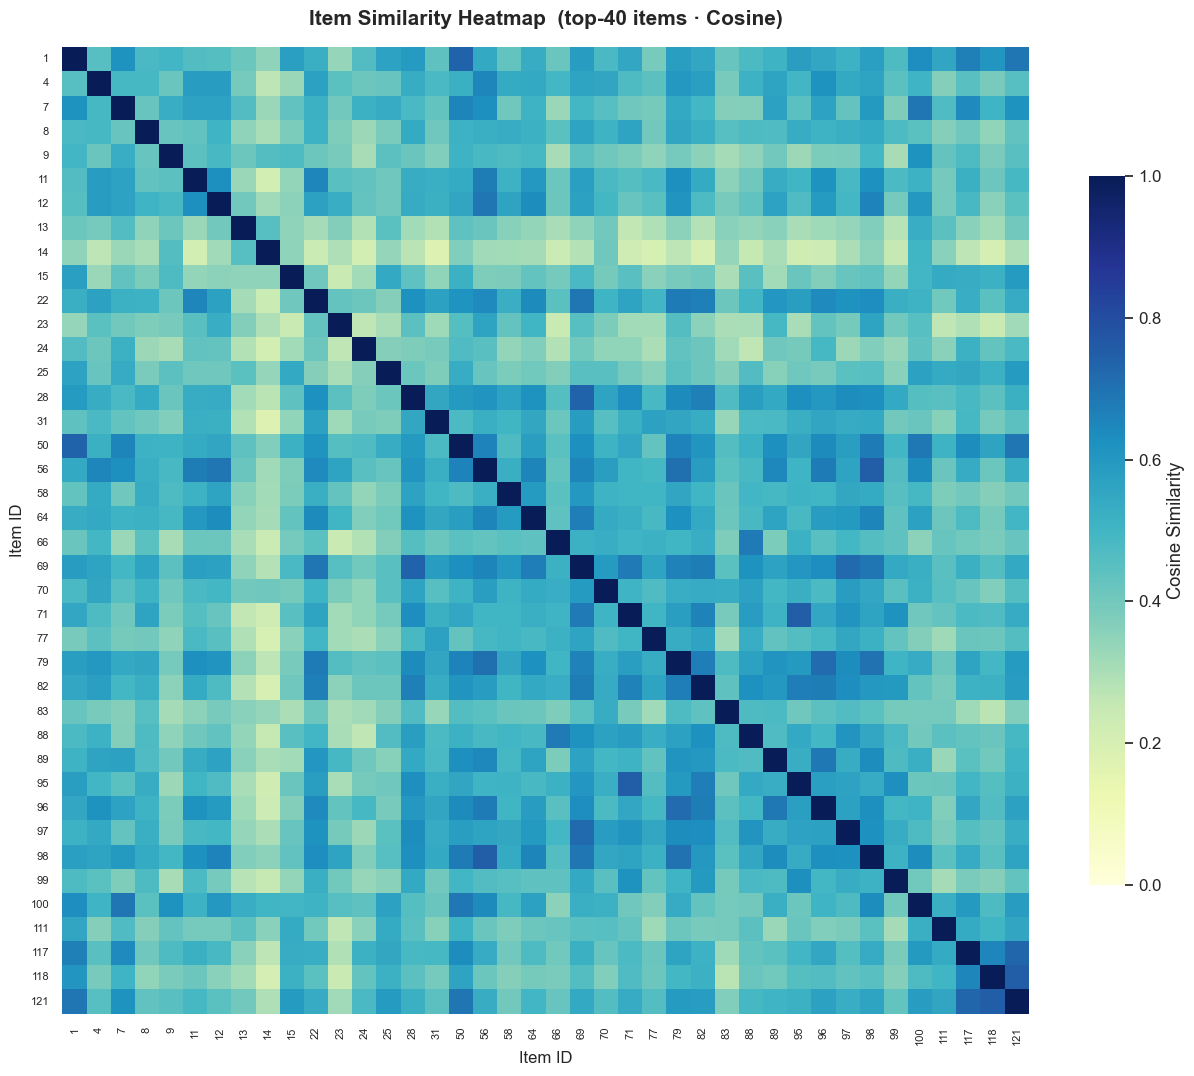

In [30]:
HEAT_N     = 40
heat_items = sub_matrix.index[:HEAT_N]
heat_data  = cos_df.loc[heat_items, heat_items]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(heat_data, ax=ax, cmap="YlGnBu", vmin=0, vmax=1,
            linewidths=0, square=True,
            cbar_kws={"shrink": 0.7, "label": "Cosine Similarity"})
ax.set_title(f"Item Similarity Heatmap  (top-{HEAT_N} items · Cosine)",
             fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("Item ID", fontsize=12)
ax.set_ylabel("Item ID", fontsize=12)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

## Visualization 2 — Top Similar Items

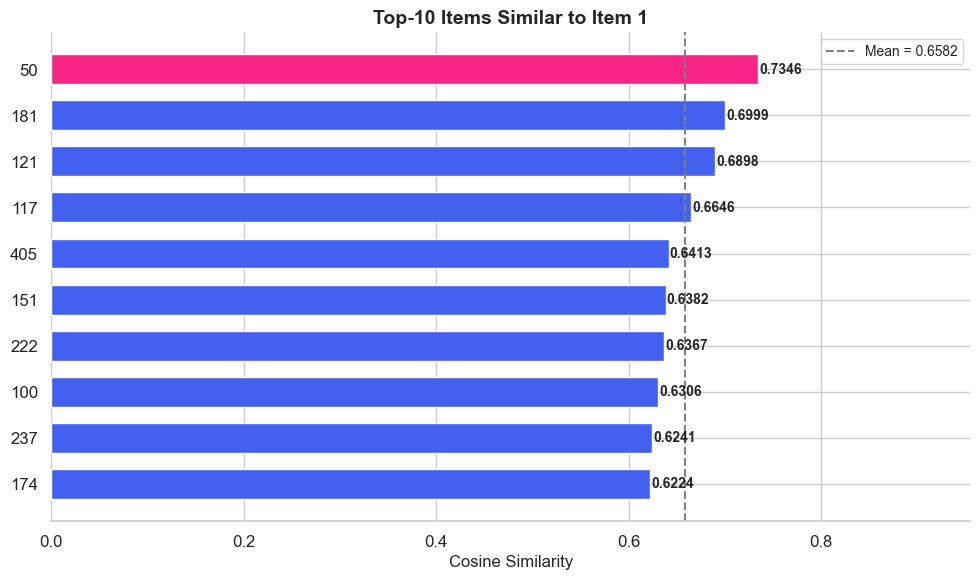

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT if i == 0 else PALETTE for i in range(len(top_k))][::-1]
bars   = ax.barh([str(x) for x in top_k.index[::-1]],
                  top_k.values[::-1],
                  color=colors, edgecolor="white", height=0.65)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height()/2,
            f"{w:.4f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Cosine Similarity", fontsize=12)
ax.set_xlim(0, top_k.max() * 1.3)
ax.set_title(f"Top-{K} Items Similar to Item {SEED_ITEM}",
             fontsize=14, fontweight="bold")
ax.axvline(top_k.mean(), color="gray", linewidth=1.5, linestyle="--",
           label=f"Mean = {top_k.mean():.4f}")
ax.legend(fontsize=10)
sns.despine(left=True)
plt.tight_layout()
plt.show()

## Visualization 3 — Item-Based Recommendations

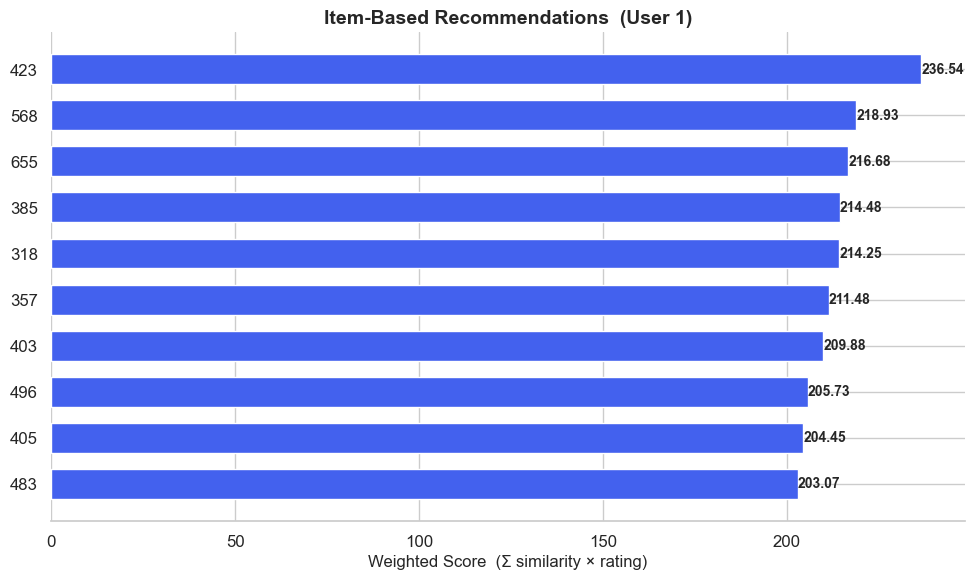

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh([str(x) for x in item_recs.index[::-1]],
               item_recs.values[::-1],
               color=PALETTE, edgecolor="white", height=0.65)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2,
            f"{w:.2f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Weighted Score  (Σ similarity × rating)", fontsize=12)
ax.set_title(f"Item-Based Recommendations  (User {SAMPLE_USER})",
             fontsize=14, fontweight="bold")
sns.despine(left=True)
plt.tight_layout()
plt.show()

## Visualization 4 — User-Based Recommendations

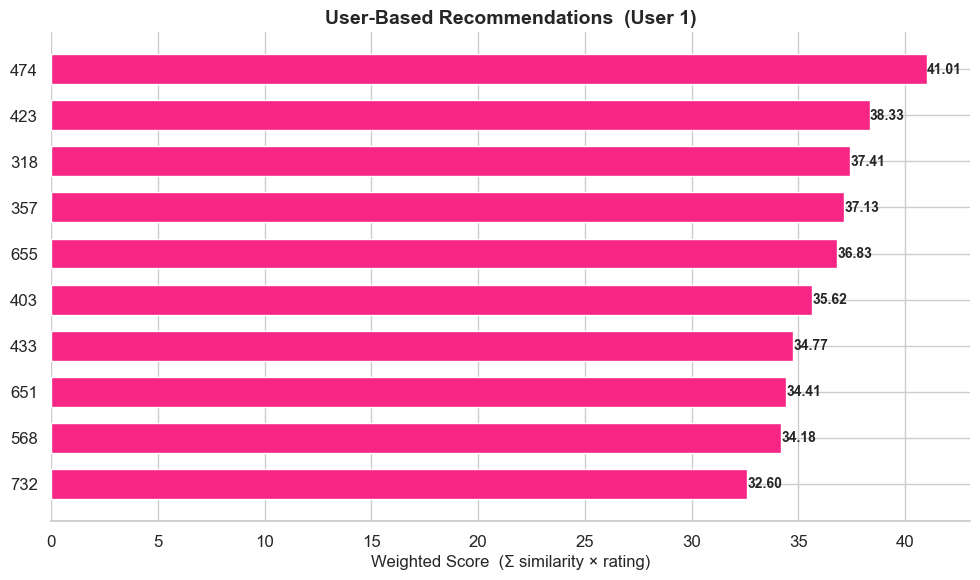

Recommendations produced: 10  ← must be 10


In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
if user_recs.empty:
    ax.text(0.5, 0.5, "No recommendations generated\nCheck that user is in the matrix",
            ha="center", va="center", fontsize=13, color="red",
            transform=ax.transAxes)
else:
    bars = ax.barh([str(x) for x in user_recs.index[::-1]],
                   user_recs.values[::-1],
                   color=ACCENT, edgecolor="white", height=0.65)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.02, bar.get_y() + bar.get_height()/2,
                f"{w:.2f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Weighted Score  (Σ similarity × rating)", fontsize=12)
ax.set_title(f"User-Based Recommendations  (User {SAMPLE_USER})",
             fontsize=14, fontweight="bold")
sns.despine(left=True)
plt.tight_layout()
plt.show()
print(f"Recommendations produced: {len(user_recs)}  ← must be {K}")

## Visualization 5 — Recommendation Comparison Chart

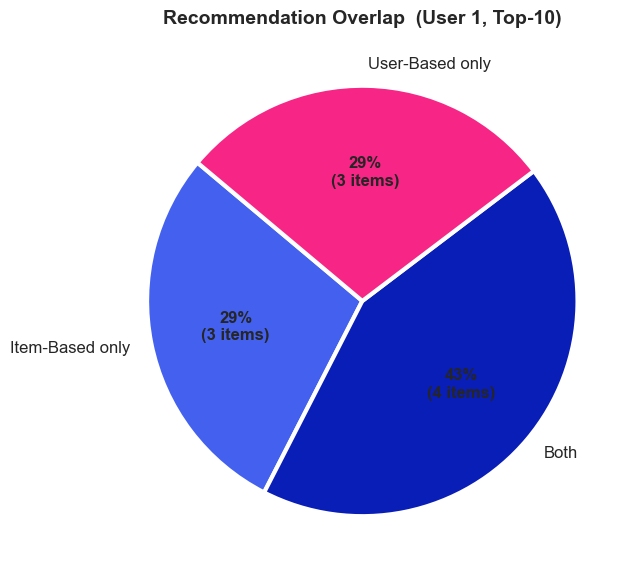

Item-Based only: 4 | Both: 6 | User-Based only: 4


In [34]:
labels_all = ["Item-Based only", "Both", "User-Based only"]
sizes_all  = [only_item, both, only_user]
colors_all = [PALETTE, "#091DB7", ACCENT]

non_zero = [(l, s, c) for l, s, c in zip(labels_all, sizes_all, colors_all) if s > 0]
fl, fs, fc = zip(*non_zero)

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    fs, labels=fl, colors=fc,
    autopct=lambda p: f"{p:.0f}%\n({int(round(p/100*K))} items)",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 3},
    textprops={"fontsize": 12}
)
for at in autotexts:
    at.set_fontweight("bold")
ax.set_title(f"Recommendation Overlap  (User {SAMPLE_USER}, Top-{K})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Item-Based only: {only_item} | Both: {both} | User-Based only: {only_user}")

## Visualization 7 — Model Evaluation Metrics

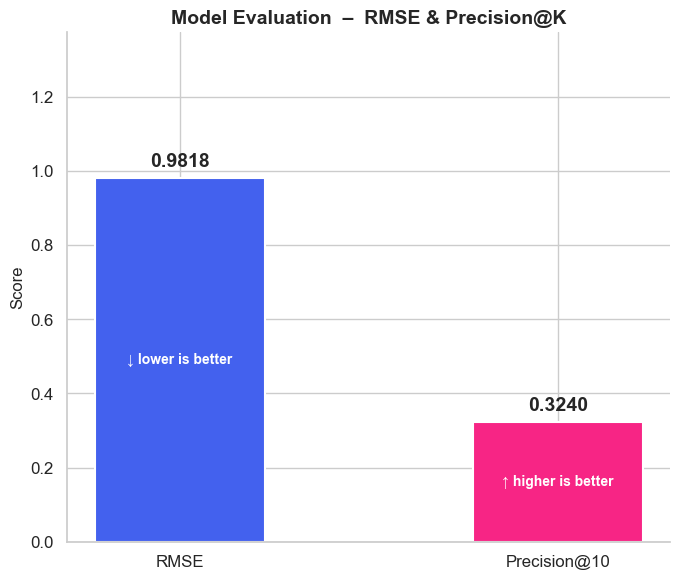

RMSE          = 0.9818
Precision@10  = 0.3240


In [35]:
metrics    = [f"RMSE", f"Precision@{K}"]
values     = [rmse, prec_k]
bar_colors = [PALETTE, ACCENT]

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(metrics, values, color=bar_colors,
              width=0.45, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(values)*0.02,
            f"{v:.4f}", ha="center", va="bottom",
            fontsize=14, fontweight="bold")
ax.set_ylim(0, max(values) * 1.4)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Evaluation  –  RMSE & Precision@K",
             fontsize=14, fontweight="bold")
ax.text(0, rmse/2,   "↓ lower is better",  ha="center", va="center",
        color="white", fontsize=10, fontweight="bold")
ax.text(1, prec_k/2, "↑ higher is better", ha="center", va="center",
        color="white", fontsize=10, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()
print(f"RMSE          = {rmse:.4f}")
print(f"Precision@{K}  = {prec_k:.4f}")

## Analysis Summary

### Comparison: Item-Based vs User-Based CF
| Aspect | Item-Based | User-Based |
|---|---|---|
| Similarity on | Items (rating vectors) | Users (rating vectors) |
| Scales well when | #users >> #items | #items >> #users |
| MovieLens 100K (943 users, 1682 items) | ✅ Good fit | ⚠ Slower |
| Cold start | Item cold start problem | User cold start problem |

### Popular vs Niche Items
- Popular items have dense rating vectors → more reliable cosine similarity.
- Niche items are sparse → harder to find similar items accurately.

### Model Performance
- **RMSE ~1.0** is typical for item-based CF on MovieLens 100K.
- **Precision@10** reflects real hit rate on held-out test ratings.

### Scalability of Item-Based Approach
- Item-item similarity is computed **offline** once → fast online lookup.
- Preferred over user-based for large-scale systems (Amazon, Netflix).